In [1]:
import os
from pathlib import Path
import statistics
from collections import defaultdict
import shutil

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from tqdm.notebook import tqdm
import seaborn as sns
  
from sklearn.cluster import DBSCAN 
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import normalize 
from sklearn.decomposition import PCA 
from sklearn import metrics
from IPython.display import Image, display

import constants as k
import utils
from calculate_instantaneous_firing_rate import calculate_firing_rates

In [2]:
data_dir = '/Users/rebekahzhang/data/neural_data'
pickle_dir = Path(os.path.join(data_dir, 'session_pickles'))
figure_dir = os.path.join(data_dir, 'figures')
# FIGURES = f'{data_dir}/figures'

In [3]:
units_vetted = pd.read_csv(os.path.join(data_dir, 'units_vetted.csv'), index_col=0).sort_values('unit_id')
sessions_vetted = pd.read_csv(os.path.join(data_dir, 'sessions_vetted.csv'), index_col=0).sort_values('num_units')

### alignment tests

In [ ]:
def get_data_for_debugging(units_vetted=units_vetted, session_id='RZ051_2024-11-19_str', unit_id=20):
    units_by_session = units_vetted.groupby("session_id")
    test_session = units_by_session.get_group(session_id)
    session_fr = test_session.loc[test_session['id'] == unit_id, "session_fr"].iloc[0]
    events, trials, units = utils.get_session_data(session_id, pickle_dir)
    spikes = units[unit_id]
    return events, trials, spikes, session_fr
events, trials, spikes, session_fr = get_data_for_debugging()

In [ ]:
time_step = 0.1
trial_count_mask = 1

# Filter trials with spikes
spikes_for_bg_fr = spikes.loc[spikes.period == k.BACKGROUND]
trials_w_bg_spikes = spikes_for_bg_fr['trial_id'].unique()
trials_for_bg_fr = trials[trials['trial_id'].isin(trials_w_bg_spikes)].copy()


forward alignment

In [ ]:
forward_align = True
if forward_align:
    anchor = k.TO_CUE_ON
    trials_for_bg_fr_forward = trials_for_bg_fr.copy()
    trials_for_bg_fr_forward['aligned_start_time'] = trials_for_bg_fr_forward['cue_on_time'] - trials_for_bg_fr_forward['cue_on_time']
    trials_for_bg_fr_forward['aligned_end_time'] = trials_for_bg_fr_forward['cue_off_time'] - trials_for_bg_fr_forward['cue_on_time']

bin_centers_bg_forward, mean_fr_bg_forward, sem_fr_bg_forward = calculate_firing_rates(
    trials_for_bg_fr_forward, spikes_for_bg_fr, anchor, time_step, trial_count_mask=5, sigma=1)
peak_fr_bg_forward = mean_fr_bg_forward.max()
peak_fr_time_bg_fr = bin_centers_bg_forward[np.argmax(mean_fr_bg_forward)]
min_fr_bg_forward = mean_fr_bg_forward.min()
min_fr_time_bg_fr = bin_centers_bg_forward[np.argmin(mean_fr_bg_forward)]
plt.plot(bin_centers_bg_forward, mean_fr_bg_forward)

background backward alignment

In [ ]:
backward_align = True
if backward_align:
    anchor = k.TO_CUE_OFF
    trials_for_bg_fr_backward = trials_for_bg_fr.copy()
    trials_for_bg_fr_backward['aligned_start_time'] = trials_for_bg_fr_backward['cue_on_time'] - trials_for_bg_fr_backward['cue_off_time']
    trials_for_bg_fr_backward['aligned_end_time'] = trials_for_bg_fr_backward['cue_off_time'] - trials_for_bg_fr_backward['cue_off_time']

bin_centers_bg_backward, mean_fr_bg_backward, sem_fr_bg_backward = calculate_firing_rates(
    trials_for_bg_fr_backward, spikes_for_bg_fr, anchor, time_step, trial_count_mask=5, sigma=1)
peak_fr_bg_backward = mean_fr_bg_backward.max()
peak_fr_time_bg_backward = bin_centers_bg_backward[np.argmax(mean_fr_bg_backward)]  # time prior to BG end
min_fr_bg_backward = mean_fr_bg_backward.min()
min_fr_time_bg_backward = bin_centers_bg_backward[np.argmin(mean_fr_bg_backward)]  # time prior to BG end
plt.plot(bin_centers_bg_backward, mean_fr_bg_backward)

### looping through all units

In [ ]:
time_step = 0.1
trial_count_mask = 5
sigma = 3

In [ ]:
def generate_unit_period_data_dict(trials, spikes, time_step, trial_count_mask, sigma):
    period_boundaries = {
        k.BACKGROUND: ["cue_on_time", "cue_off_time"], 
        k.WAIT: ["cue_off_time", "decision_time"], 
        k.CONSUMPTION: ["decision_time", "trial_length"]}
    alignments = ["forward_align", "backward_align"]
    anchor_time_to_anchor = {
        "cue_on_time": k.TO_CUE_ON,
        "cue_off_time": k.TO_CUE_OFF,
        "decision_time": k.TO_DECISION,
    }

    unit_period_data_dict = {}
    for period, boundaries in period_boundaries.items():
        spikes_for_period_fr = spikes.loc[spikes.period == period]
        trials_w_period_spikes = spikes_for_period_fr['trial_id'].unique()
        trials_for_period_fr = trials[trials['trial_id'].isin(trials_w_period_spikes)].copy()
        period_start_time = trials_for_period_fr[boundaries[0]]
        period_end_time = trials_for_period_fr[boundaries[1]]
        for alignment in alignments:
            anchor_time = boundaries[0] if alignment == "forward_align" else boundaries[1]
            anchor = anchor_time_to_anchor.get(anchor_time)
            if not anchor:
                continue
            trials_for_period_fr_aligned = trials_for_period_fr.copy()
            trials_for_period_fr_aligned['aligned_start_time'] = period_start_time - trials_for_period_fr_aligned[anchor_time]
            trials_for_period_fr_aligned['aligned_end_time'] = period_end_time - trials_for_period_fr_aligned[anchor_time]
            # print(f"Period: {period}, Alignment: {alignment}, Anchor: {anchor}")

            bin_centers, mean_fr, sem_fr = calculate_firing_rates(
                trials_for_period_fr_aligned, spikes_for_period_fr, anchor, time_step, trial_count_mask, sigma)

            # print(f"{period}_{alignment} mean: {mean_fr.mean()}, max: {max_fr}, min: {min_fr}")
            # Handle empty/non-empty cases
            if len(mean_fr) == 0:
                # Default values if no data
                unit_period_data_dict[f"{period}_{alignment}_mean_fr"] = np.nan
                unit_period_data_dict[f"{period}_{alignment}_sem_fr"] = np.nan
                unit_period_data_dict[f"{period}_{alignment}_max_fr"] = np.nan
                unit_period_data_dict[f"{period}_{alignment}_max_fr_time"] = np.nan
                unit_period_data_dict[f"{period}_{alignment}_min_fr"] = np.nan
                unit_period_data_dict[f"{period}_{alignment}_min_fr_time"] = np.nan
            else:
                # Compute metrics if data exists
                unit_period_data_dict[f"{period}_{alignment}_mean_fr"] = np.mean(mean_fr)
                unit_period_data_dict[f"{period}_{alignment}_sem_fr"] = np.mean(sem_fr)
                unit_period_data_dict[f"{period}_{alignment}_max_fr"] = np.max(mean_fr)
                unit_period_data_dict[f"{period}_{alignment}_max_fr_time"] = bin_centers[np.argmax(mean_fr)]
                unit_period_data_dict[f"{period}_{alignment}_min_fr"] = np.min(mean_fr)
                unit_period_data_dict[f"{period}_{alignment}_min_fr_time"] = bin_centers[np.argmin(mean_fr)]
    # unit_period_data_df = pd.DataFrame.from_dict(unit_period_data, orient='index').T
    return unit_period_data_dict

# single unit test before plotting all
# unit_period_data_dict = generate_unit_period_data_dict(trials, spikes, time_step, trial_count_mask, sigma)

In [ ]:
units_by_session = units_vetted.groupby("session_id")
unit_data_list = []
for session_id, session_units in units_by_session:
    events, trials, units = utils.get_session_data(session_id, pickle_dir)
    for i, (_, unit_info) in enumerate(session_units.iterrows()):
        unit_id = unit_info['unit_id']
        spikes = units[i]
        unit_period_data_dict = generate_unit_period_data_dict(
                trials, spikes, time_step, trial_count_mask, sigma)
        unit_data = {'unit_id': unit_id} | unit_period_data_dict
        unit_data_list.append(unit_data)
unit_data_df = pd.DataFrame(unit_data_list)

In [ ]:
unit_data_df

In [ ]:
unit_data_df.to_csv(os.path.join(data_dir, 'units_period_data.csv'))

# Clustering!!

In [31]:
unit_data_df_all = pd.read_csv(os.path.join(data_dir, 'units_period_data.csv'))

In [32]:
# unit_data_df_all

In [33]:
features_to_drop = ['unit_id']
X = unit_data_df_all.drop(features_to_drop, axis=1) 
X.ffill(inplace=True)
X.head() 

,Unnamed: 0,background_forward_align_mean_fr,background_forward_align_sem_fr,background_forward_align_max_fr,background_forward_align_max_fr_time,background_forward_align_min_fr,background_forward_align_min_fr_time,background_backward_align_mean_fr,background_backward_align_sem_fr,background_backward_align_max_fr,...,wait_backward_align_max_fr,wait_backward_align_max_fr_time,wait_backward_align_min_fr,wait_backward_align_min_fr_time,consumption_forward_align_mean_fr,consumption_forward_align_sem_fr,consumption_forward_align_max_fr,consumption_forward_align_max_fr_time,consumption_forward_align_min_fr,consumption_forward_align_min_fr_time
0,0,3.293233,0.411578,5.584883,2.95,2.507731,1.15,3.456809,0.414131,5.563223,...,3.516573,-0.35,0.677069,-9.95,3.614684,0.362732,4.424284,0.05,1.824807,3.05
1,1,1.263699,0.536337,1.895884,2.15,0.907574,0.35,0.754210,0.365964,1.260446,...,3.068580,0.05,0.019954,-4.85,2.108133,0.317368,4.066152,0.05,0.196818,3.05
2,2,6.604246,0.611778,8.961262,1.75,2.999002,3.25,6.307550,0.608673,7.774296,...,8.050673,-9.65,4.497889,-1.25,9.316483,0.661192,11.892532,0.95,6.038034,3.05
3,3,5.092263,0.443438,7.484930,0.05,1.973876,3.25,4.570957,0.405179,7.282302,...,6.749180,-5.35,1.657900,0.05,4.719345,0.409918,6.507869,2.55,3.005633,0.05
4,4,4.659199,0.668345,5.905860,1.65,3.938547,0.75,4.667528,0.696815,7.394282,...,4.111911,-6.15,0.694700,-8.25,4.188190,0.462381,5.964282,0.85,2.040717,3.05


In [34]:
# Scaling the data to bring all the attributes to a comparable level 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 
  
# Normalizing the data so that  
# the data approximately follows a Gaussian distribution 
X_normalized = normalize(X_scaled) 
  
# Converting the numpy array into a pandas DataFrame 
X_normalized = pd.DataFrame(X_normalized) 

In [35]:
from sklearn.cluster import AgglomerativeClustering
# agg = AgglomerativeClustering(n_clusters=5)
agg = AgglomerativeClustering()
labels = agg.fit_predict(X_normalized)

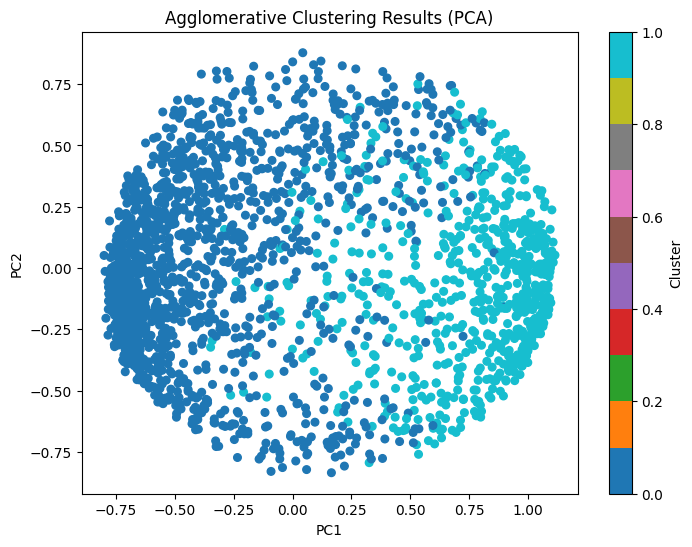

In [36]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', s=30)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Agglomerative Clustering Results (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [37]:
labels

array([0, 0, 0, ..., 1, 1, 0])

In [44]:
clustered_data = unit_data_df_all.copy()
clustered_data['cluster'] = labels

In [45]:
clustered_data

,Unnamed: 0,unit_id,background_forward_align_mean_fr,background_forward_align_sem_fr,background_forward_align_max_fr,background_forward_align_max_fr_time,background_forward_align_min_fr,background_forward_align_min_fr_time,background_backward_align_mean_fr,background_backward_align_sem_fr,...,wait_backward_align_max_fr_time,wait_backward_align_min_fr,wait_backward_align_min_fr_time,consumption_forward_align_mean_fr,consumption_forward_align_sem_fr,consumption_forward_align_max_fr,consumption_forward_align_max_fr_time,consumption_forward_align_min_fr,consumption_forward_align_min_fr_time,cluster
0,0,RZ034_2024-07-13_str_unit-106,3.293233,0.411578,5.584883,2.95,2.507731,1.15,3.456809,0.414131,...,-0.35,0.677069,-9.95,3.614684,0.362732,4.424284,0.05,1.824807,3.05,0
1,1,RZ034_2024-07-13_str_unit-109,1.263699,0.536337,1.895884,2.15,0.907574,0.35,0.754210,0.365964,...,0.05,0.019954,-4.85,2.108133,0.317368,4.066152,0.05,0.196818,3.05,0
2,2,RZ034_2024-07-13_str_unit-110,6.604246,0.611778,8.961262,1.75,2.999002,3.25,6.307550,0.608673,...,-9.65,4.497889,-1.25,9.316483,0.661192,11.892532,0.95,6.038034,3.05,0
3,3,RZ034_2024-07-13_str_unit-111,5.092263,0.443438,7.484930,0.05,1.973876,3.25,4.570957,0.405179,...,-5.35,1.657900,0.05,4.719345,0.409918,6.507869,2.55,3.005633,0.05,0
4,4,RZ034_2024-07-13_str_unit-112,4.659199,0.668345,5.905860,1.65,3.938547,0.75,4.667528,0.696815,...,-6.15,0.694700,-8.25,4.188190,0.462381,5.964282,0.85,2.040717,3.05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2184,2184,RZ065_2025-02-22_str_unit-93,0.699510,0.142716,1.058492,13.15,0.107398,19.05,0.686125,0.139469,...,-8.75,0.042993,-17.25,0.975874,0.277659,1.318461,2.35,0.393200,0.05,0
2185,2185,RZ065_2025-02-22_str_unit-94,3.208471,1.028920,12.794896,13.55,0.000000,18.15,4.126096,1.210598,...,-0.05,0.003951,-8.55,4.352873,1.466200,7.055435,1.45,1.736038,0.35,0
2186,2186,RZ070_2025-02-13_str_unit-7,32.941681,1.965428,36.757059,2.65,27.782456,0.05,28.945480,1.730500,...,-4.45,14.949321,0.05,37.564463,1.278269,52.887585,0.05,20.258344,3.05,1
2187,2187,RZ070_2025-02-13_str_unit-8,22.556814,1.402297,28.236851,2.85,18.414011,0.05,18.384261,1.149826,...,-1.85,12.667703,-5.35,19.664537,0.843808,24.805225,0.05,12.105709,3.05,1


In [46]:
clusters = sorted(clustered_data['cluster'].unique())
for cluster in clusters:
    
    cluster_ids = clustered_data[clustered_data['cluster']==cluster]['unit_id']
    print("\n")
    print("--------------------------------------------------------")
    print(f"Cluster {cluster}")
    print(f"Units in cluster: {len(cluster_ids)}")



--------------------------------------------------------
Cluster 0
Units in cluster: 1496


--------------------------------------------------------
Cluster 1
Units in cluster: 693


In [ ]:
def copy_unit_image_to_cluster_folder(unit, cluster, version):
    src = os.path.join(figure_dir, unit) + '.png'
    print(src)
    home_folder = os.path.join(figure_dir, f'clustered-{version}')
    cluster_folder = os.path.join(home_folder, cluster)
    if not os.path.exists(home_folder):
        os.makedirs(home_folder)
    if not os.path.exists(cluster_folder):
        os.makedirs(cluster_folder)     
    shutil.copy(src, cluster_folder)

Ferran's code

In [ ]:
db = DBSCAN(min_samples=5).fit(X_normalized)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

In [ ]:
clustered_data = X_normalized
clustered_data['cluster'] = labels
clustered_data['unit_id'] = unit_data_df_all['unit_id']

In [ ]:
clustered_data

In [ ]:
def plot_raster_per_unit(unit: str):
    test_image = os.path.join(figure_dir, unit) + '.png'
    display(Image(test_image))


# Cluster plots:

In [ ]:
clusters = sorted(clustered_data['cluster'].unique())
for cluster in clusters:
    
    cluster_ids = clustered_data[clustered_data['cluster']==cluster]['unit_id']
    print("\n")
    print("--------------------------------------------------------")
    print(f"Cluster {cluster}")
    print(f"Units in cluster: {len(cluster_ids)}")
    # cluster_ids.head(2).map(plot_raster_per_unit)


In [ ]:
def copy_unit_image_to_cluster_folder(unit, cluster, version):
    src = os.path.join(FIGURES, unit) + '.png'
    print(src)
    home_folder = os.path.join(FIGURES, f'clustered-{version}')
    cluster_folder = os.path.join(home_folder, cluster)
    if not os.path.exists(home_folder):
        os.makedirs(home_folder)
    if not os.path.exists(cluster_folder):
        os.makedirs(cluster_folder)     
    shutil.copy(src, cluster_folder)

In [ ]:
VERSION = "2023-05-31"
clusters = sorted(clustered_data['cluster'].unique())
for cluster in clusters:
    cluster_ids = clustered_data[clustered_data['cluster']==cluster]['unit_id']
    copy_file = lambda x: copy_unit_image_to_cluster_folder(x, str(cluster), VERSION) 
    cluster_ids.map(copy_file)